# Step 1 — Analysis units

Spec: `CLAUDE.md` §6 step 1, as amended in `SPEC_CHANGELOG.md` (2026-09-15).

**Units are DWR WY2023 field polygons** (DWR / Land IQ Statewide Crop Mapping, subclass T20
Strawberries) in Monterey and Santa Cruz (DWR `COUNTY`, the county of the field centroid) where
strawberries were **the only crop of the water year** (sequence A, 1 Oct 2022 – 30 Sep 2023).
Fields touching permanent water (JRC GSW `occurrence` > 50; any 30 m water pixel overlapping the
field) are excluded.

Sequence B (strawberries first, then another crop) and C (planted after another crop) fields are
**kept in the table as flagged non-units**, with their crop sequence and T20 peak-greenness date.
All T20 fields go into the Earth Engine asset `projects/cropczyk/assets/strawberry_fields_dwr_wy2023`
with `is_unit` = 1 for units.

Carried-forward caveats (CLAUDE.md §8): neither DWR nor CDL is ground truth; that sequence A fields
had a crop in the ground in March 2023 is agronomic reasoning, to be checked with February 2023 NDVI
in Step 3.

Part 2 keeps the earlier **CDL 250 m cells as the comparison** (127 cells under the 2023 rule, 15
under the both-years rule). The threshold sensitivity is retired; its cell is kept for the record.

Outputs in `data/derived/` (never overwritten; delete a file to regenerate):
`01_units_dwr.geojson`, `01_units_dwr.csv`, `01_units_map_v3.html`, `01_gsw_perm_water_30m.tif`
(cache, not committed), plus the CDL comparison files from earlier runs. Figure:
`figures/fig1_study_area.png`.

**CHECKPOINT:** the human confirms the units are strawberry fields, not greenhouses, nurseries,
or misclassified lettuce.

In [1]:
import json
import time

import ee
import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import shapes
from shapely.geometry import box, shape

import common as C
from cdl import native_tif
from dwr import FILES, SEQUENCES, load_fields, strawberry_sequences
from maps import HALO, add_north_arrow, add_scale_bar, s2_basemap

ee.Initialize(project=C.EE_PROJECT)
C.DERIVED.mkdir(parents=True, exist_ok=True)
C.FIGURES.mkdir(parents=True, exist_ok=True)
ASSET = "projects/cropczyk/assets/strawberry_fields_dwr_wy2023"
DWR_FILE = FILES[2023][0]
print("Earth Engine project:", C.EE_PROJECT, "| DWR file:", DWR_FILE)

Earth Engine project: cropczyk | DWR file: i15_crop_mapping_2023_final.gdb.zip


## Study area

In [2]:
counties_fc = ee.FeatureCollection(C.COUNTIES).filter(ee.Filter.inList("GEOID", C.COUNTY_GEOIDS))
region = counties_fc.geometry()
counties = gpd.GeoDataFrame.from_features(counties_fc.getInfo()["features"], crs="EPSG:4326")
counties = counties[["GEOID", "NAME", "geometry"]].sort_values("GEOID").reset_index(drop=True)
counties_m = counties.to_crs(C.GRID_CRS)
towns = gpd.GeoDataFrame({"name": list(C.TOWNS)}, crs="EPSG:4326",
                         geometry=gpd.points_from_xy(*zip(*C.TOWNS.values()))).to_crs(C.GRID_CRS)
print(counties[["GEOID", "NAME"]].to_string(index=False))
print("dataset:", C.COUNTIES)

GEOID       NAME
06053   Monterey
06087 Santa Cruz
dataset: TIGER/2018/Counties


# Part 1 — DWR field units

## Strawberry fields and their place in the WY2023 crop sequence

In [3]:
fields_all = load_fields(2023, list(counties.NAME))
t20 = strawberry_sequences(fields_all, wy=2023).reset_index(drop=True)
seq_counts = t20.sequence.value_counts().to_dict()
assert seq_counts == {"A": 1320, "B": 611, "C": 4}, f"sequence counts differ from 01b_dwr_check: {seq_counts}"

by_seq = t20.groupby(["sequence", "COUNTY"]).agg(fields=("ACRES", "size"), acres=("ACRES", "sum")).round(0)
print(by_seq.to_string())
print("\n" + "\n".join(f"  {k}: {v}" for k, v in SEQUENCES.items()))
print(f"\nDWR WY2023 fields in the two counties: {len(fields_all):,}; with T20 in any slot: {len(t20):,} | "
      f"date window: WY2023 (1 Oct 2022 – 30 Sep 2023) | dataset: DWR Statewide Crop Mapping ({DWR_FILE})")

C:\Users\austi\CROPCZYK\strawberry-index-insurance\.venv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


                     fields    acres
sequence COUNTY                     
A        Monterey       939  12444.0
         Santa Cruz     381   2240.0
B        Monterey       478   6031.0
         Santa Cruz     133   1458.0
C        Monterey         1     22.0
         Santa Cruz       3     25.0

  A: strawberries the only crop of the water year
  B: strawberries first, then another crop
  C: strawberries planted after another crop

DWR WY2023 fields in the two counties: 18,668; with T20 in any slot: 1,935 | date window: WY2023 (1 Oct 2022 – 30 Sep 2023) | dataset: DWR Statewide Crop Mapping (i15_crop_mapping_2023_final.gdb.zip)


## Permanent water

JRC GSW `occurrence` > 50 on its native 30 m grid, downloaded once for the fields' extent and
vectorised; a field is flagged if any water pixel overlaps it.

In [4]:
t20_ll = t20.to_crs("EPSG:4326")
bbox = tuple(float(v) for v in np.round(t20_ll.total_bounds + np.array([-0.01, -0.01, 0.01, 0.01]), 3))
gsw = ee.Image(C.GSW).select("occurrence")
WATER_TIF = native_tif(gsw.unmask(0).gt(C.PERMANENT_WATER).toByte(),
                       C.DERIVED / "01_gsw_perm_water_30m.tif", bbox, proj_image=gsw, n_tiles=2)
with rasterio.open(WATER_TIF) as src:
    water = src.read(1)
    water_polys = gpd.GeoDataFrame(
        geometry=[shape(s) for s, v in shapes(water, mask=water == 1, transform=src.transform)],
        crs=src.crs)
f = t20_ll.to_crs(water_polys.crs)[["UniqueID", "geometry"]]
pairs = gpd.sjoin(f, water_polys, predicate="intersects")
overlap = [f.geometry[i].intersection(water_polys.geometry[j]).area > 0 for i, j in zip(pairs.index, pairs.index_right)]
touching = set(pairs.UniqueID[np.array(overlap, dtype=bool)]) if len(pairs) else set()
t20["touches_perm_water"] = t20.UniqueID.isin(touching)
print(f"water pixels in extent: {int(water.sum()):,} | T20 fields touching permanent water: {len(touching)} "
      f"(by sequence: {t20[t20.touches_perm_water].sequence.value_counts().to_dict()})")
print(f"dataset: {C.GSW} (occurrence > {C.PERMANENT_WATER})")

water pixels in extent: 3,681,983 | T20 fields touching permanent water: 0 (by sequence: {})
dataset: JRC/GSW1_4/GlobalSurfaceWater (occurrence > 50)


## Unit table

In [5]:
t20["is_unit"] = (t20.sequence == "A") & ~t20.touches_perm_water
t20["unit_id"] = t20.UniqueID.astype(str)
assert t20.unit_id.is_unique
t20["geom_acres"] = t20.area / 4046.8564224
cent = t20.centroid
t20["x_3310"], t20["y_3310"] = cent.x.round(1), cent.y.round(1)
cent_ll = cent.to_crs("EPSG:4326")
t20["lon"], t20["lat"] = cent_ll.x.round(6), cent_ll.y.round(6)
for c in ["t20_peak_date", "crop_after_peak_date"]:
    t20[c] = pd.to_datetime(t20[c]).dt.strftime("%Y-%m-%d")
units = t20[t20.is_unit]

summary = pd.DataFrame({
    "fields": t20.groupby("sequence").size(),
    "acres": t20.groupby("sequence").ACRES.sum().round(0),
    "touch permanent water": t20.groupby("sequence").touches_perm_water.sum(),
    "units": t20.groupby("sequence").is_unit.sum(),
})
print(summary.to_string())
print("\nUnits by county:", units.COUNTY.value_counts().to_dict(),
      f"| unit acres (DWR ACRES): {units.ACRES.sum():,.0f}")
print("Sequence B, T20 peak month (acres):",
      t20[t20.sequence == "B"].groupby(t20.t20_peak_date.str[:7]).ACRES.sum().round(0).to_dict())

COLS = ["unit_id", "is_unit", "sequence", "COUNTY", "ACRES", "geom_acres", "MULTIUSE", "MAIN_CROP",
        "crop_sequence", "t20_slot", "t20_peak_date", "crop_before", "crop_after", "crop_after_peak_date",
        "touches_perm_water", "lon", "lat", "x_3310", "y_3310"]
GEOJSON, CSV = C.DERIVED / "01_units_dwr.geojson", C.DERIVED / "01_units_dwr.csv"
for path, write in [(GEOJSON, lambda p: t20[COLS + ["geometry"]].to_crs("EPSG:4326").to_file(p, driver="GeoJSON")),
                    (CSV, lambda p: t20[COLS].to_csv(p, index=False))]:
    if path.exists():
        print(f"{path.name} exists; not overwritten (delete it to regenerate)")
    else:
        write(path)
        print(f"Wrote {path.name}")
print(f"n units = {len(units)} (of {len(t20)} T20 fields) | date window: WY2023 | "
      f"datasets: DWR ({DWR_FILE}), {C.GSW}")

          fields    acres  touch permanent water  units
sequence                                               
A           1320  14683.0                      0   1320
B            611   7489.0                      0      0
C              4     47.0                      0      0

Units by county: {'Monterey': 939, 'Santa Cruz': 381} | unit acres (DWR ACRES): 14,683
Sequence B, T20 peak month (acres): {'2022-10': 4164.0, '2022-11': 1986.0, '2022-12': 529.0, '2023-01': 613.0, '2023-02': 136.0, '2023-03': 60.0}
01_units_dwr.geojson exists; not overwritten (delete it to regenerate)
01_units_dwr.csv exists; not overwritten (delete it to regenerate)
n units = 1320 (of 1935 T20 fields) | date window: WY2023 | datasets: DWR (i15_crop_mapping_2023_final.gdb.zip), JRC/GSW1_4/GlobalSurfaceWater


## Earth Engine asset

All T20 fields with their attributes, uploaded once with `Export.table.toAsset`. If the asset exists
it is not overwritten. Geometry is sent as planar (non-geodesic) EPSG:4326 polygons.

In [6]:
def asset_exists(asset_id):
    try:
        ee.data.getAsset(asset_id)
        return True
    except ee.EEException:
        return False


def py(v):
    if isinstance(v, (np.bool_, bool)):
        return int(v)
    if isinstance(v, np.generic):
        v = v.item()
    return None if (v is None or (isinstance(v, float) and np.isnan(v)) or v == "") else v


if asset_exists(ASSET):
    print(f"{ASSET} exists; not overwritten")
else:
    ll = t20.to_crs("EPSG:4326")
    feats = []
    for geom, (_, r) in zip(ll.geometry, ll[COLS].iterrows()):
        props = {k: py(v) for k, v in r.items()}
        feats.append(ee.Feature(ee.Geometry(json.loads(json.dumps(geom.__geo_interface__)), None, False),
                                {k: v for k, v in props.items() if v is not None}))
    task = ee.batch.Export.table.toAsset(collection=ee.FeatureCollection(feats),
                                         description="strawberry_fields_dwr_wy2023", assetId=ASSET)
    task.start()
    t0 = time.time()
    while task.status()["state"] in ("UNSUBMITTED", "READY", "RUNNING") and time.time() - t0 < 900:
        time.sleep(20)
    status = task.status()
    print(f"export task {status['state']} after {time.time() - t0:.0f} s")
    if status["state"] != "COMPLETED":
        raise RuntimeError(f"asset export did not complete: {status}")

fc = ee.FeatureCollection(ASSET)
n_asset, n_units_asset = fc.size().getInfo(), fc.filter(ee.Filter.eq("is_unit", 1)).size().getInfo()
assert n_asset == len(t20) and n_units_asset == len(units), (n_asset, n_units_asset)
print(f"asset {ASSET}: {n_asset} features, {n_units_asset} with is_unit = 1")
print(f"n units = {len(units)} | date window: WY2023 | dataset: {ASSET}")

projects/cropczyk/assets/strawberry_fields_dwr_wy2023 exists; not overwritten

asset projects/cropczyk/assets/strawberry_fields_dwr_wy2023: 1935 features, 1320 with is_unit = 1
n units = 1320 | date window: WY2023 | dataset: projects/cropczyk/assets/strawberry_fields_dwr_wy2023


# Part 2 — Comparison: CDL 250 m cells

The earlier unit definition, kept as the comparison (`CLAUDE.md` §5, §6). 250 m cells in EPSG:3310,
CDL class 221; cells touching permanent water excluded; county by cell centroid.

In [7]:
grid = ee.Projection(C.GRID_CRS, [C.CELL_M, 0, 0, 0, -C.CELL_M, 0])


def cdl(year):
    col = ee.ImageCollection(C.CDL).filterDate(f"{year}-01-01", f"{year + 1}-01-01")
    n = col.size().getInfo()
    assert n == 1, f"expected 1 CDL image for {year}, found {n}"
    return col.first().select("cropland")


def strawberry_fraction(year):
    img = cdl(year)
    return (img.eq(C.CDL_STRAWBERRY).unmask(0).setDefaultProjection(img.projection())
            .reduceResolution(ee.Reducer.mean(), maxPixels=1024)
            .reproject(grid).rename(f"frac_{year}"))


perm_water = (gsw.unmask(0).gt(C.PERMANENT_WATER).setDefaultProjection(gsw.projection())
              .reduceResolution(ee.Reducer.max(), maxPixels=1024)
              .reproject(grid).rename("perm_water"))

CAND = C.DERIVED / f"01_candidate_cells_ge{round(C.CANDIDATE_MIN_FRAC * 100)}.geojson"


def cell_boxes(cols, rows):
    s = C.CELL_M
    return [box(c * s, -(r + 1) * s, (c + 1) * s, -r * s) for c, r in zip(cols, rows)]


if CAND.exists():
    cand = gpd.read_file(CAND)
    print(f"Loaded cached {CAND.name} (delete it to recompute)")
else:
    f22, f23 = strawberry_fraction(2022), strawberry_fraction(2023)
    keep = f22.gte(C.CANDIDATE_MIN_FRAC).Or(f23.gte(C.CANDIDATE_MIN_FRAC))
    stack = f22.addBands(f23).addBands(perm_water).updateMask(keep)
    fc_cells = stack.sample(region=region, projection=grid, geometries=True, dropNulls=True, tileScale=4)
    n = fc_cells.size().getInfo()
    assert n < 5000, f"{n} cells is too many for getInfo; switch to an ee.batch export"
    pts = gpd.GeoDataFrame.from_features(fc_cells.getInfo()["features"], crs="EPSG:4326").to_crs(C.GRID_CRS)
    cand = pd.DataFrame({
        "col": np.floor(pts.geometry.x / C.CELL_M).astype(int),
        "row": np.floor(-pts.geometry.y / C.CELL_M).astype(int),
        "frac_2022": pts["frac_2022"], "frac_2023": pts["frac_2023"],
        "perm_water": pts["perm_water"].astype(int),
    })
    cand["x_3310"] = cand.col * C.CELL_M + C.CELL_M / 2
    cand["y_3310"] = -(cand.row * C.CELL_M + C.CELL_M / 2)
    cand.insert(0, "unit_id", [f"c{c}_r{r}" for c, r in zip(cand.col, cand.row)])
    cent_c = gpd.GeoDataFrame(cand[["unit_id"]], crs=C.GRID_CRS,
                              geometry=gpd.points_from_xy(cand.x_3310, cand.y_3310))
    joined = gpd.sjoin(cent_c, counties_m, how="left", predicate="within")
    joined = joined[~joined.index.duplicated()]
    cand["county_geoid"], cand["county"] = joined["GEOID"].values, joined["NAME"].values
    ll_c = cent_c.to_crs("EPSG:4326").geometry
    cand["lon"], cand["lat"] = ll_c.x.round(6).values, ll_c.y.round(6).values
    cand = gpd.GeoDataFrame(cand, geometry=cell_boxes(cand.col, cand.row), crs=C.GRID_CRS)
    cand = cand.sort_values(["row", "col"]).reset_index(drop=True)
    cand.to_crs("EPSG:4326").to_file(CAND, driver="GeoJSON")
    print(f"Wrote {CAND.name}")

cand = gpd.GeoDataFrame(cand.drop(columns="geometry"), crs=C.GRID_CRS, geometry=cell_boxes(cand.col, cand.row))
MIN = C.MIN_STRAWBERRY_FRAC
cand["water"] = cand.perm_water > 0
cand["unit_y2023"] = (cand.frac_2023 >= MIN) & ~cand.water
cand["unit_both"] = (cand.frac_2022 >= MIN) & (cand.frac_2023 >= MIN) & ~cand.water
cells_y2023, cells_both = cand[cand.unit_y2023], cand[cand.unit_both]
print(f"CDL cells, 2023 rule: {len(cells_y2023)} | both-years rule: {len(cells_both)} | "
      f"n units (DWR) = {len(units)} | date window: CDL 2022 and 2023 | datasets: {C.CDL} (class "
      f"{C.CDL_STRAWBERRY}), {C.GSW}")

Loaded cached 01_candidate_cells_ge40.geojson (delete it to recompute)
CDL cells, 2023 rule: 127 | both-years rule: 15 | n units (DWR) = 1320 | date window: CDL 2022 and 2023 | datasets: USDA/NASS/CDL (class 221), JRC/GSW1_4/GlobalSurfaceWater


### Retired: threshold sensitivity (kept for the record)

Retired on 2026-09-15 because field boundaries replace gridded cells. Printed from the saved CSV.

In [8]:
print(pd.read_csv(C.DERIVED / "01_threshold_sensitivity.csv").to_string(index=False))
print(f"n units (DWR) = {len(units)} | date window: CDL 2022 and 2023 | dataset: {C.CDL}")

threshold  2023 rule: units  Monterey  Santa Cruz  ≤ 5 km of Pajaro  ≤ 8 km of Pajaro  excluded, water  both-years rule: units
      40%               388       295          93                14               113                0                      65
      50%               219       155          64                 5                72                0                      32
      60%               127        80          47                 2                46                0                      15
n units (DWR) = 1320 | date window: CDL 2022 and 2023 | dataset: USDA/NASS/CDL


### CDL 2022 vs 2023 (diagnostic from the first run)

In [9]:
first = ee.ImageCollection(C.CDL).filterDate("2023-01-01", "2024-01-01").first()
class_names = dict(zip([int(v) for v in first.get("cropland_class_values").getInfo().split(",")],
                       first.get("cropland_class_names").getInfo().split(",")))


def cross_classes(src_year, where_year, top=8):
    hist = (cdl(src_year).updateMask(cdl(where_year).eq(C.CDL_STRAWBERRY))
            .reduceRegion(ee.Reducer.frequencyHistogram(), region, maxPixels=1e10, tileScale=4)
            .get("cropland").getInfo())
    df = pd.DataFrame({"class": [int(float(k)) for k in hist], "pixels": list(hist.values())})
    df["name"] = df["class"].map(class_names)
    df["ha"] = (df.pixels * 900 / 1e4).round(0).astype(int)
    df["share"] = (df.pixels / df.pixels.sum()).map("{:.1%}".format)
    return df.sort_values("pixels", ascending=False).head(top)[["class", "name", "pixels", "ha", "share"]]


print("CDL 2022 class of pixels that CDL 2023 labels Strawberries:")
print(cross_classes(2022, 2023).to_string(index=False))
print("\nCDL 2023 class of pixels that CDL 2022 labels Strawberries:")
print(cross_classes(2023, 2022).to_string(index=False))
print(f"\nn units (DWR) = {len(units)} | date window: CDL crop years 2022 and 2023 | dataset: {C.CDL}")

CDL 2022 class of pixels that CDL 2023 labels Strawberries:


 class                 name       pixels   ha share
   152            Shrubland 16322.819608 1469 31.9%
   221         Strawberries 13855.152941 1247 27.1%
   176        Grass/Pasture  8335.000000  750 16.3%
    36              Alfalfa  3412.772549  307  6.7%
    61 Fallow/Idle Cropland  1828.000000  165  3.6%
   111           Open Water  1466.000000  132  2.9%
   195  Herbaceous Wetlands  1026.000000   92  2.0%
    12           Sweet Corn   573.000000   52  1.1%

CDL 2023 class of pixels that CDL 2022 labels Strawberries:


 class                  name       pixels   ha share
   221          Strawberries 13855.152941 1247 90.5%
   152             Shrubland   978.000000   88  6.4%
   195   Herbaceous Wetlands   200.000000   18  1.3%
   176         Grass/Pasture    87.000000    8  0.6%
   142      Evergreen Forest    46.000000    4  0.3%
    37 Other Hay/Non Alfalfa    32.000000    3  0.2%
   131                Barren    28.000000    3  0.2%
   111            Open Water    26.000000    2  0.2%

n units (DWR) = 1320 | date window: CDL crop years 2022 and 2023 | dataset: USDA/NASS/CDL


# Figures

## Figure 1 — study area and units

Basemap: Sentinel-2 true-colour median, Aug–Sep 2023, scenes < 10 % cloud, Cloud Score+ mask
(cached GeoTIFFs, not committed). Town positions approximate. The Pajaro River is not drawn; the
flood extent layer will show the channel.

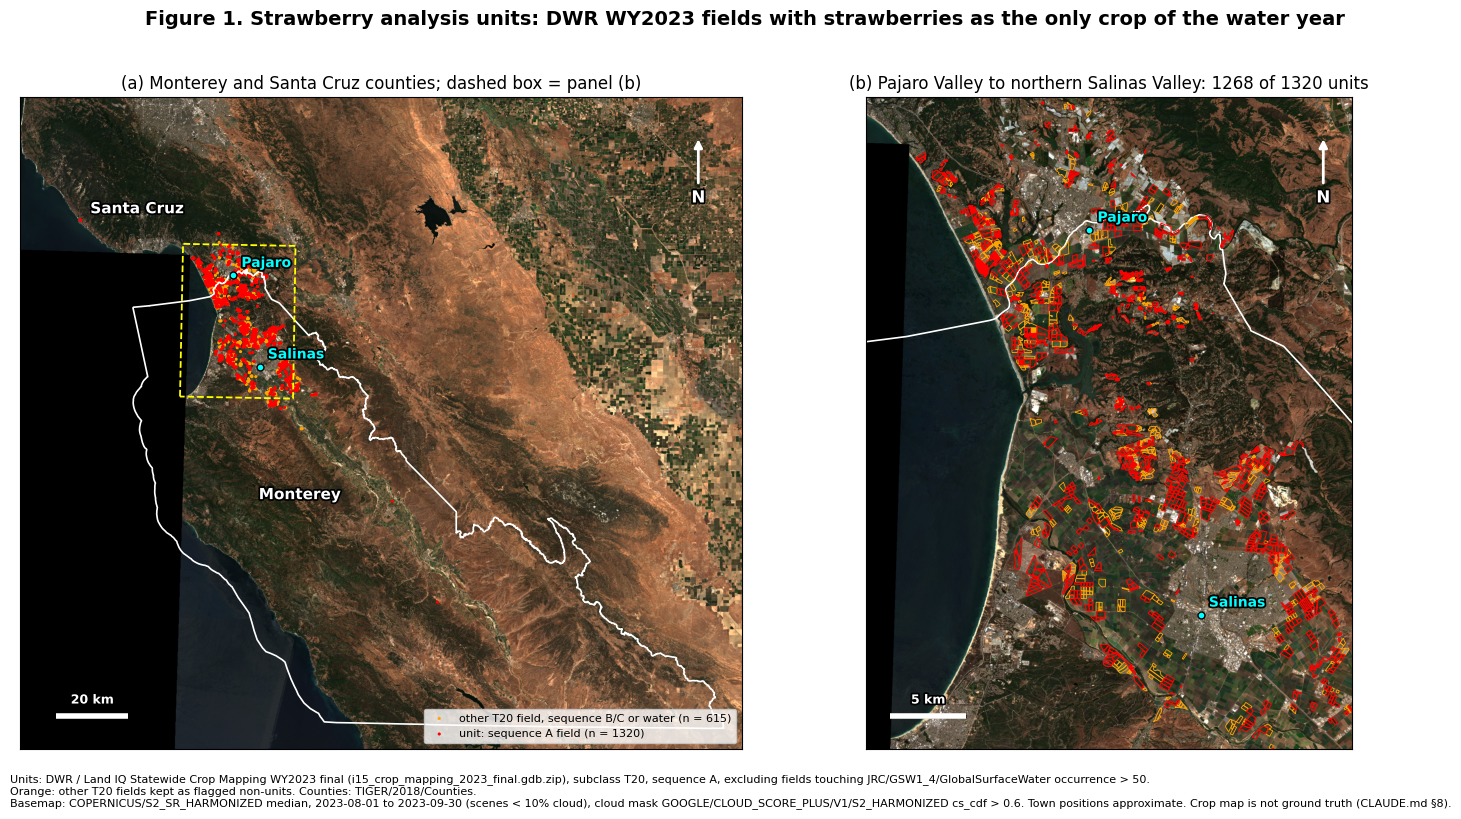

Saved fig1_study_area.png | n units = 1320 (1268 in zoom panel), other T20 fields 615 | date window: WY2023; basemap 2023-08-01 to 2023-09-30 (scenes < 10% cloud) | datasets: DWR (i15_crop_mapping_2023_final.gdb.zip), JRC/GSW1_4/GlobalSurfaceWater, TIGER/2018/Counties, COPERNICUS/S2_SR_HARMONIZED, GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED


In [10]:
OVERVIEW_LL = tuple(np.round(counties.total_bounds + np.array([-0.05, -0.05, 0.05, 0.05]), 3))
ZOOM_LL = (-121.90, 36.60, -121.55, 36.98)
BASEMAP_WINDOW = ("2023-08-01", "2023-10-01")
BASEMAP_LABEL = "2023-08-01 to 2023-09-30 (scenes < 10% cloud)"
ov_rgb, ov_ext = s2_basemap(C.DERIVED / "01_basemap_overview.tif", OVERVIEW_LL, 120, *BASEMAP_WINDOW)
zm_rgb, zm_ext = s2_basemap(C.DERIVED / "01_basemap_zoom.tif", ZOOM_LL, 20, *BASEMAP_WINDOW)

zoom_box = gpd.GeoSeries([box(*ZOOM_LL)], crs="EPSG:4326").to_crs(C.GRID_CRS)
others = t20[~t20.is_unit]
in_zoom = units.centroid.within(zoom_box.iloc[0])

fig, (a, b) = plt.subplots(1, 2, figsize=(15, 8.2))
for ax, rgb, ext in [(a, ov_rgb, ov_ext), (b, zm_rgb, zm_ext)]:
    ax.imshow(rgb, extent=ext, origin="upper")
    counties_m.boundary.plot(ax=ax, color="white", lw=1.2)
    for _, t in towns.iterrows():
        ax.plot(t.geometry.x, t.geometry.y, marker="o", ms=5, color="cyan", mec="black")
        ax.annotate(t["name"], (t.geometry.x, t.geometry.y), xytext=(6, 6), textcoords="offset points",
                    color="cyan", fontsize=10, fontweight="bold", path_effects=HALO)
    ax.set_xlim(ext[0], ext[1])
    ax.set_ylim(ext[2], ext[3])
    ax.set_xticks([])
    ax.set_yticks([])

uc, oc = units.centroid, others.centroid
a.scatter(oc.x, oc.y, s=5, c="orange", edgecolors="none", label=f"other T20 field, sequence B/C or water (n = {len(others)})")
a.scatter(uc.x, uc.y, s=5, c="red", edgecolors="none", label=f"unit: sequence A field (n = {len(units)})")
zoom_box.boundary.plot(ax=a, color="yellow", lw=1.3, ls="--")
for _, c in counties_m.iterrows():
    p = c.geometry.representative_point()
    a.annotate(c["NAME"], (p.x, p.y), color="white", fontsize=11, fontweight="bold", ha="center", path_effects=HALO)
a.legend(loc="lower right", fontsize=8)
a.set_title("(a) Monterey and Santa Cruz counties; dashed box = panel (b)")

others.boundary.plot(ax=b, color="orange", lw=0.6)
units.boundary.plot(ax=b, color="red", lw=0.7)
b.set_title(f"(b) Pajaro Valley to northern Salinas Valley: {int(in_zoom.sum())} of {len(units)} units")

add_scale_bar(a, 20)
add_scale_bar(b, 5)
add_north_arrow(a)
add_north_arrow(b)
fig.suptitle("Figure 1. Strawberry analysis units: DWR WY2023 fields with strawberries as the only crop "
             "of the water year", fontsize=14, fontweight="bold")
fig.text(0.01, 0.005,
         f"Units: DWR / Land IQ Statewide Crop Mapping WY2023 final ({DWR_FILE}), subclass T20, sequence A, "
         f"excluding fields touching {C.GSW} occurrence > {C.PERMANENT_WATER}.\n"
         f"Orange: other T20 fields kept as flagged non-units. Counties: {C.COUNTIES}.\n"
         f"Basemap: {C.S2} median, {BASEMAP_LABEL}, cloud mask {C.S2_CLOUD} cs_cdf > {C.CLEAR_CS_CDF}. "
         "Town positions approximate. Crop map is not ground truth (CLAUDE.md §8).",
         fontsize=8, va="bottom")
fig.tight_layout(rect=(0, 0.06, 1, 0.96))
FIG1 = C.FIGURES / "fig1_study_area.png"
fig.savefig(FIG1, dpi=200)
plt.show()
print(f"Saved {FIG1.name} | n units = {len(units)} ({int(in_zoom.sum())} in zoom panel), other T20 fields "
      f"{len(others)} | date window: WY2023; basemap {BASEMAP_LABEL} | datasets: DWR ({DWR_FILE}), {C.GSW}, "
      f"{C.COUNTIES}, {C.S2}, {C.S2_CLOUD}")

## Interactive check map

Esri World Imagery. Red: units (sequence A). Orange: sequence B. Violet: sequence C. Grey: sequence A
fields excluded for permanent water. Yellow (off by default): CDL 2023-rule cells, the comparison.
Hover a field for its crop sequence and T20 peak-greenness date.

In [11]:
MAP = C.DERIVED / "01_units_map_v3.html"
if MAP.exists():
    print(f"{MAP.name} exists; not overwritten (delete it to regenerate)")
else:
    tips = ["unit_id", "sequence", "crop_sequence", "t20_peak_date", "ACRES", "COUNTY"]

    def layer(df, name, color, show=True, fields=tips):
        if df.empty:  # folium cannot build a tooltip for an empty layer
            print(f"layer skipped, no features: {name}")
            return
        d = df[fields + ["geometry"]].to_crs("EPSG:4326")
        folium.GeoJson(d, name=name, show=show,
                       style_function=lambda _: {"color": color, "weight": 1.5, "fillOpacity": 0.15},
                       tooltip=folium.GeoJsonTooltip(fields=fields)).add_to(m)

    m = folium.Map(location=[36.80, -121.72], zoom_start=11, tiles=None, control_scale=True)
    folium.TileLayer("Esri.WorldImagery", name="Esri World Imagery").add_to(m)
    folium.GeoJson(counties, name="Counties",
                   style_function=lambda _: {"color": "white", "weight": 2, "fill": False}).add_to(m)
    cells = cells_y2023.assign(frac_2023=cells_y2023.frac_2023.round(2))
    layer(cells, f"CDL 2023-rule cells, comparison (n = {len(cells)})", "yellow", show=False,
          fields=["unit_id", "frac_2023", "county"])
    layer(t20[(t20.sequence == "A") & t20.touches_perm_water], "Sequence A, excluded: permanent water", "lightgray")
    layer(t20[t20.sequence == "C"], f"Sequence C (n = {int((t20.sequence == 'C').sum())})", "violet")
    layer(t20[t20.sequence == "B"], f"Sequence B (n = {int((t20.sequence == 'B').sum())})", "orange")
    layer(units, f"Units: sequence A (n = {len(units)})", "red")
    folium.LayerControl(collapsed=False).add_to(m)
    m.save(MAP)
    print(f"Wrote {MAP.name}")
print(f"n units = {len(units)} | date window: WY2023 | datasets: DWR ({DWR_FILE}), {C.CDL}, {C.GSW}")

layer skipped, no features: Sequence A, excluded: permanent water


Wrote 01_units_map_v3.html
n units = 1320 | date window: WY2023 | datasets: DWR (i15_crop_mapping_2023_final.gdb.zip), USDA/NASS/CDL, JRC/GSW1_4/GlobalSurfaceWater
